# EISpac Wrapper for MSSL

**Credits to Will Barnes (Sunpy) and NRL (EISpac) for a lot of the code shown!**

The __[EISpac](https://github.com/USNavalResearchLaboratory/eispac)__ software provides a set of tools for analyzing Hinode/EIS data within a python environment. The general approach is as follows:

> Sets of level 1 HDF5 files are processed from the latest EIS level 0 fits files and made available online by the NRL EIS team at https://eis.nrl.navy.mil/. The HDF5 files come in pairs of "data" and "header" files which contain corrected count rates, the calibration curve needed to convert counts into intensity, and all of the associated metadata and pointing information.

> This package provides python classes and functions that can read these hdf5 files, perform all of the necessary calibration and pointing adjustments. Also included are functions for fitting the intensity profiles using the same template files and underlying methodology that is used in the IDL SolarSoft environment.

The EISpac package could be downloaded by pressing here __[(Download EISpac)](https://github.com/USNavalResearchLaboratory/eispac)__ and following the website's instruction. This tutorial intends to introduce you the basics of EISpac, and provide a EISpac wrapper for ease of use.

## Python vs IDL package handling

Instead of adding package dependencies in the ssw file, python does this by importing packages before you coding script.

In [ ]:
import eispac

## Downloading data:

The first good thing about EISpac is prepping. EISpac prepped every data available, and put them in https://eis.nrl.navy.mil/level1/. You can either download files from the website, or do the following

In [40]:
data = 'eis_20140202_141952.data.h5'
a = eispac.download.download_hdf5_data(data)

+ downloading https://eis.nrl.navy.mil/level1/hdf5/2014/02/02/eis_20140202_141952.data.h5 -> data_eis/eis_20140202_141952.data.h5


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

eis_20140202_141952.data.h5.part:   0%|          | 0.00/157M [00:00<?, ?B/s]


+ downloading https://eis.nrl.navy.mil/level1/hdf5/2014/02/02/eis_20140202_141952.head.h5 -> data_eis/eis_20140202_141952.head.h5


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

eis_20140202_141952.head.h5.part:   0%|          | 0.00/227k [00:00<?, ?B/s]

This automatically creates a folder called **data_eis/** and put the "data.h5" and "head.h5" (data and header) file into that folder. These are then the data and header files that we need for processing!

## Python vs IDL EIS data processing

In IDL, in order to process EIS data properly, there are several steps we need to take. Let's use **eis_file** as our data file.

1. template=eis_read_template('template_12_fexii_195.txt')
2. windata = eis_getwindata(eis_file, 195.12, /refill)
3. eis_auto_fit, windata, fitdata_coro, offset=offset, template=template

In Python, we have similar procedures, but fewer and more definite steps. NRL has processed every data available to get windata, and defined templates for everyone to use! So no need to do any eis_trimwindata/ have our own template based on different studies again!

### Get template and windata (datacube)

In [41]:
# Getting template from eispac database
template_name = "fe_12_195_119.2c.template.h5"
template = eispac.read_template(eispac.data.get_fit_template_filepath(template_name))

# eis_getwindata equivalent -> eispac.read_cube
cube = eispac.read_cube(f'data_eis/{data}', window=template.central_wave)

Data file,
   /Users/ato/scripts/python_code/asheis/data_eis/eis_20140202_141952.data.h5
Header file,
   /Users/ato/scripts/python_code/asheis/data_eis/eis_20140202_141952.head.h5
Found a wavelength 195.11 [Angstroms] in window 1
INFO: uncertainty should have attribute uncertainty_type. [astropy.nddata.nddata]


### Fitting the line

In [42]:
# Fitting the data
fit_res = eispac.fit_spectra(cube, template, ncpu='max')

 + computing fits for 60 exposures, each with 160 spectra
 + running mpfit on 8 cores (of 8)
 + working on exposure 060

Finished computing fits!
   runtime : 0:00:19.475328
   9600 spectra fit without issues
   0 spectra have < 7 good data points
   0 spectra have bad or invalid parameters


In default, EISpac uses all your computer cores to fit the data. This drastically slows down your computer's speed. If you want EISpac to fit in the background, change **'max'** into the number of cores you want.

> e.g. *fit_res = eispac.fit_spectra(cube, template, ncpu=2)*

## Getting map from the fitted spectra

After we have used the template and datacube(windata) to obtain the fitted spectra, it's time for us to get useful maps. Here, we use the **get_map** function, and define *component* as the centroid number. So for our 195.12 window, the 0th(1st) centroid is our FeXII 195.119 line.

INFO: uncertainty should have attribute uncertainty_type. [astropy.nddata.nddata]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


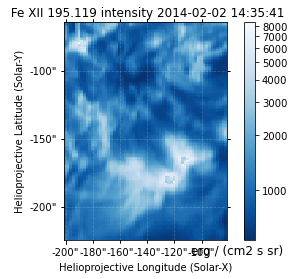

In [46]:
map_eis = fit_res.get_map(component=0,measurement='intensity') # From fitdata get map
map_eis.peek()

In [47]:
time_range = a.Time(map_eis.date_start-10*u.minute,
                    end=map_eis.date_end,
                    near=map_eis.date_average)

AttributeError: 'download_hdf5_data' object has no attribute 'Time'

## Main code for getting data products of EIS

Since the above process could be quite repetitive, I have created an EISpac black box that can just be run!

*Description: I have included everything into a class, this enables us to define an object, and allow different functions to perform on top of the object.*

In [ ]:
# a lot of information are gathered through Will Barnes Hinode-14 sunpy tutorial - It will be a good manor to cite the sunpy team

from pathlib import Path
import eispac
import sunpy
from matplotlib import colors
import matplotlib.pyplot as plt
from datetime import datetime
from astropy.visualization import ImageNormalize, quantity_support


def load_plotting_routine():
    fig = plt.figure()
    fig.set_dpi(300)
    BIGGER_SIZE=9
    SMALLER_SIZE=8
    plt.rc('font', size=BIGGER_SIZE)  # controls default text sizes
    plt.rc('axes', titlesize=BIGGER_SIZE)  # fontsize of the axes title
    plt.rc('axes', labelsize=SMALLER_SIZE)  # fontsize of the x and y labels
    plt.rc('xtick', labelsize=SMALLER_SIZE)  # fontsize of the tick labels
    plt.rc('ytick', labelsize=SMALLER_SIZE)  # fontsize of the tick labels
    plt.rc('legend', fontsize=BIGGER_SIZE)  # legend fontsize
    plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

def load_axes_labels():
    plt.xlabel('x (arcsec)')
    plt.ylabel('y (arcsec)')


class asheis:
    
    def __init__(self, filename):
        self.filename = filename
        self.dict = {
            "fe_12_195" : ["fe_12_195_119.2c.template.h5",0],
            "ar_14_194" : ["ar_14_194_396.6c.template.h5",5],
            "ca_14_193" : ["ar_14_194_396.6c.template.h5",1],
            "si_10_258" : ["si_10_258_375.1c.template.h5",0],
            "s_10_264" : ["s__10_264_233.1c.template.h5",0],
            "fe_13_202" : ["fe_13_202_044.1c.template.h5",0],
            "fe_13_203" : ["fe_13_203_826.2c.template.h5",1]
        }
        
    def fit_data(self,line,product):
        """
        In default asheis saves the fitdata in data_eis/, where you can recover and plot intensity, velocity and width map again.
        """
        template_name=self.dict[f'{line}'][0]
        # print(self.filename.replace("data.h5",template_name))
        path = Path(f'{self.filename}'.replace("data.h5",template_name).replace(".template",f"-{self.dict[f'{line}'][1]}.fit"))
        if path.is_file() == False:
            template = eispac.read_template(eispac.data.get_fit_template_filepath(template_name))
            cube = eispac.read_cube(self.filename, window=template.central_wave)
            fit_res = eispac.fit_spectra(cube, template, ncpu='max')
            save_filepaths = eispac.save_fit(fit_res)
        else:
            fit_res=eispac.read_fit(path)

        fit_res.fit[f'{product}'] = fit_res.shift2wave(fit_res.fit[f'{product}'],wave=195.119)
        return fit_res
    
    def directory_setup(self, amap):
        date = amap.date.strftime("%Y_%m_%d__%H_%M_%S")
        Path(f'images/fits/').mkdir(parents=True, exist_ok=True)
        Path(f'images/{amap.measurement.lower().split()[-1]}/').mkdir(parents=True, exist_ok=True)
        amap.save(f"images/fits/eis_{date}_{'_'.join(amap.measurement.lower().split())}.fits", overwrite=True)
        return date
    
    def plot_map(self, date, amap, colorbar=False, savefig=True):
        load_plotting_routine()
        amap.plot()
        if colorbar==True: plt.colorbar() 
        load_axes_labels()
        # plt.savefig(f'{date}/eis_{m.measurement.lower().replace(" ","_").replace(".","_")}.png')
        if savefig==True: plt.savefig(f'images/{amap.measurement.lower().split()[-1]}/eis_{date}_{amap.measurement.lower().replace(" ","_").replace(".","_")}.png')
        # plt.savefig(f'fitted_data/{amap.measurement.lower().split()[-1]}/eis_{date}_{amap.measurement.lower().replace(" ","_").replace(".","_")}.png')

    def get_intensity(self, line):
        fit_res = self.fit_data(line,'int') # Get fitdata
        m = fit_res.get_map(self.dict[f'{line}'][1],measurement='intensity') # From fitdata get map
        date = self.directory_setup(m) # Creating directories
        self.plot_map(date, m) # Plot maps
        
    def get_velocity(self, line, vmin=-10,vmax=10):
        fit_res = self.fit_data(line,'vel')
        m = fit_res.get_map(component = self.dict[f'{line}'][1],measurement='velocity')
        date = self.directory_setup(m)
        m.plot_settings['norm'] = ImageNormalize(vmin=vmin,vmax=vmax) # adjusting the velocity saturation
        self.plot_map(date, m, colorbar=True)
        
    def get_width(self, line):
        fit_res = self.fit_data(line,'vel')
        m = fit_res.get_map(component = self.dict[f'{line}'][1],measurement='width')
        date = self.directory_setup(m)
        self.plot_map(date, m, colorbar=True)

    def get_composition(self, linepair, vmin=0,vmax=4):
        if linepair == "SiS":
            lines=['si_10_258','s_10_264','Si X-S X 1']
        # elif linepair == "CaAr":
        #     lines=['ca_14_193','ar_14_194','Ca XIV-Ar XIV 1'] 
        else:
            print('No line database can be found. Add your line in code.')
        
        template_names=[self.dict[lines[0]][0],self.dict[lines[1]][0]]
        templates = [eispac.read_template(eispac.data.get_fit_template_filepath(t)) for t in template_names]
        for t in templates:
            cube = eispac.read_cube(self.filename, window=t.central_wave)
            fit_res = eispac.fit_spectra(cube, t, ncpu='max')
            fit_res.fit['int'] = fit_res.shift2wave(fit_res.fit['int'],wave=195.119)
            m = fit_res.get_map(component = self.dict[lines[0]][1], measurement='intensity')
            date = m.date.strftime("%Y_%m_%d__%H_%M_%S")
            # Path(f'{date}/fitted_data/').mkdir(parents=True, exist_ok=True)
            # m.save(f"{date}/fitted_data/eis_{'_'.join(m.measurement.lower().split())}.fits", overwrite=True)
            Path(f'images/fits/').mkdir(parents=True, exist_ok=True)
            Path(f'images/sis_composition/').mkdir(parents=True, exist_ok=True)
            m.save(f"images/fits/eis_{date}_{'_'.join(m.measurement.lower().split())}.fits", overwrite=True)
            lines.append(f"eis_{date}_{'_'.join(m.measurement.lower().split())}.fits")
        m_Si = sunpy.map.Map(f'images/fits/{lines[-2]}')
        m_S = sunpy.map.Map(f'images/fits/{lines[-1]}')
        m_SiS = m_Si
        m_SiS.meta['line_id'] = lines[2]
        m_SiS.save(f"images/fits/eis_{'_'.join(m_SiS.measurement.lower().split())}.fits", overwrite=True)
        m_SiS = sunpy.map.Map(m_Si.data/m_S.data, m_Si.meta)
        # m_SiS.peek(vmax=4,cmap='RdYlBu')
        load_plotting_routine()
        m_SiS.plot(vmin=vmin, vmax=vmax, norm=colors.Normalize(), cmap='CMRmap')
        # plt.figure()
        plt.colorbar()
        load_axes_labels()
        # plt.savefig(f'{date}/eis_{m_SiS.measurement.lower().replace(" ","_").replace(".","_")}.png')
        plt.savefig(f'fitted_data/sis_composition/eis_{date}_{m_SiS.measurement.lower().replace(" ","_").replace(".","_")}.png')


## Getting data products

In order to get the maps using what we defined above, do the following - get_intensity, get_velocity and get_width.

Then we define the specific line that we want to use. For example, FeXII 195.12 is called 'fe_12_195'.

For getting Si/S composition maps, you can do file.get_composition('SiS').

In [ ]:
from asheis import asheis
file = asheis(f'data_eis/{data}')
file.get_intensity('fe_12_195')

In [ ]:
file.get_velocity('fe_12_195')

In [ ]:
file.get_width('fe_12_195')

In [ ]:
file.get_composition('SiS')

## Looping the fitting process

Sometimes we want to loop the fitting process for say 100 files! We can do the following:

In [44]:
from asheis import asheis
import glob

files = glob.glob('data_eis/*.data.h5')
"""
This (glob.glob) reads everything .data.h5 files in the specfic directory.
Similar to IDL's files = file_search('data_eis/*.data.h5')
"""

for i in files:
    myfits = asheis(i)
    myfits.get_intensity('fe_12_195')
    myfits.get_velocity('fe_12_195')
    myfits.get_width('fe_12_195')

Data file,
   /Users/ato/scripts/python_code/asheis/data_eis/eis_20210101_112132.data.h5
Header file,
   /Users/ato/scripts/python_code/asheis/data_eis/eis_20210101_112132.head.h5
Found a wavelength 195.11 [Angstroms] in window 3
INFO: uncertainty should have attribute uncertainty_type. [astropy.nddata.nddata]
 + computing fits for 41 exposures, each with 184 spectra
 + running mpfit on 8 cores (of 8)


Process ForkPoolWorker-39:
Process ForkPoolWorker-37:
Process ForkPoolWorker-35:
Process ForkPoolWorker-40:
Process ForkPoolWorker-38:
Process ForkPoolWorker-36:
Process ForkPoolWorker-34:
Process ForkPoolWorker-33:
Traceback (most recent call last):
  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/process.py", line 99, in run
    self._target(*self._args, **self._kwargs)
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()


KeyboardInterrupt: 

  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/process.py", line 99, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/process.py", line 99, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/pool.py", line 110, in worker
    task = get()
  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/pool.py", line 110, in worker
    task = get()
  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/queues.py", line 352, in get
    res = self._reader.recv_bytes()
  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/pool.py", line 110, in worker
    task = get()
  File "/Users/ato/anaconda3/lib/python3.7/multiprocessing/queues.py

## Getting Fit Result

Before we process anything, we have to first readthe fitdata

In [ ]:
fit_res=eispac.read_fit('data_eis/eis_20140202_102527.fe_12_195_119.2c-0.fit.h5')

In [ ]:
fit_wave_cube, fit_inten_cube = fit_res.get_fit_profile(component=[0,1])
sum_fit_inten = fit_inten_cube.sum(axis=2)
fit_x, fit_y = fit_res.get_fit_profile(component=0)


In [ ]:
fit_inten_cube

## Reading .fits file in IDL

We can read the .fits (IDL-.sav) files into IDL by doing

In [ ]:
data = readfits('eis_2010_09_01__00_05_08_fe_xii_195.119_intensity.fits',header)